In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [46]:
df = pd.read_csv('placement_1.csv')

In [47]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [48]:
df.isnull().sum()

cgpa       0
package    0
dtype: int64

In [49]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


Text(0, 0.5, 'Package(in lpa)')

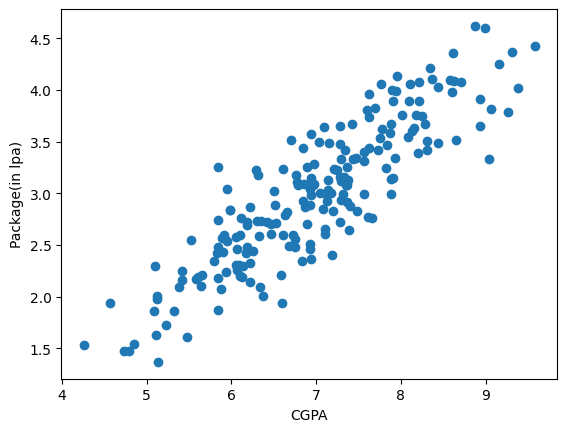

In [51]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [52]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [53]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [54]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
lr = LinearRegression()

In [58]:
lr.fit(X_train.values,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [64]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [65]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

array([3.89111601])

In [66]:
lr.predict(X_test.iloc[1].values.reshape(1,1))

array([3.09324469])

In [67]:
lr.predict(X_test.iloc[2].values.reshape(1,1))

array([2.38464568])

Text(0, 0.5, 'Package(in lpa)')

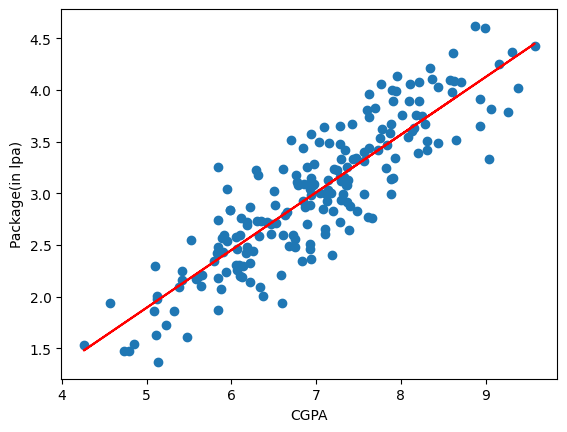

In [68]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train.values),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [69]:
m = lr.coef_

In [70]:
m

array([0.55795197])

In [71]:
b = lr.intercept_

In [72]:
b

np.float64(-0.8961119222429126)

In [73]:
data = pd.read_csv('linear_regression_dataset.csv')

In [74]:
data.head()

,input,output
0,37.454012,128.573581
1,95.071431,347.348494
2,73.199394,281.753832
3,59.865848,204.884478
4,15.601864,80.233687


In [75]:
data.isnull().sum()

input     0
output    0
dtype: int64

Text(0, 0.5, 'output')

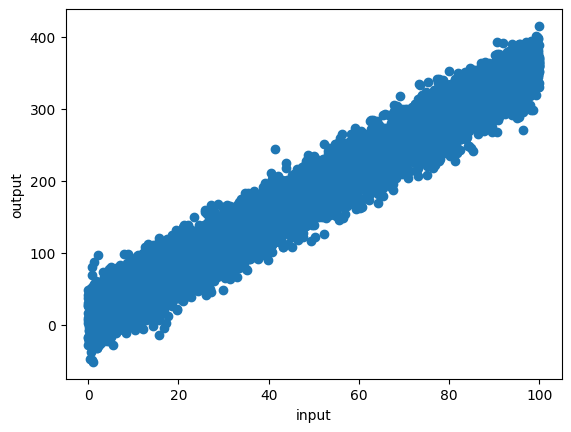

In [76]:
plt.scatter(data['input'],data['output'])
plt.xlabel('input')
plt.ylabel('output')

In [77]:
f = data.iloc[:,0:1]
e = data.iloc[:,-1]

In [78]:
f

,input
0,37.454012
1,95.071431
2,73.199394
3,59.865848
4,15.601864
...,...
11995,0.464448
11996,87.366866
11997,30.732518
11998,93.858886


In [79]:
e

0        128.573581
1        347.348494
2        281.753832
3        204.884478
4         80.233687
            ...    
11995      8.061189
11996    321.767321
11997    111.533540
11998    312.698733
11999    145.008346
Name: output, Length: 12000, dtype: float64

In [80]:
from sklearn.model_selection import train_test_split
f_train,f_test,e_train,e_test = train_test_split(f,e,test_size=0.2,random_state=2)

In [81]:
from sklearn.linear_model import LinearRegression

In [82]:
lr = LinearRegression()

In [83]:
lr.fit(f_train.values,e_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
f_test.head(2)

,input
7104,26.167137
5878,44.808549


In [85]:
e_test.head(2)

7104    131.148657
5878    154.562649
Name: output, dtype: float64

In [86]:
lr.predict(f_test.iloc[0].values.reshape(1,1))

array([101.94419789])

In [87]:
lr.predict(f_test.iloc[1].values.reshape(1,1))

array([167.05423298])

Text(0, 0.5, 'output')

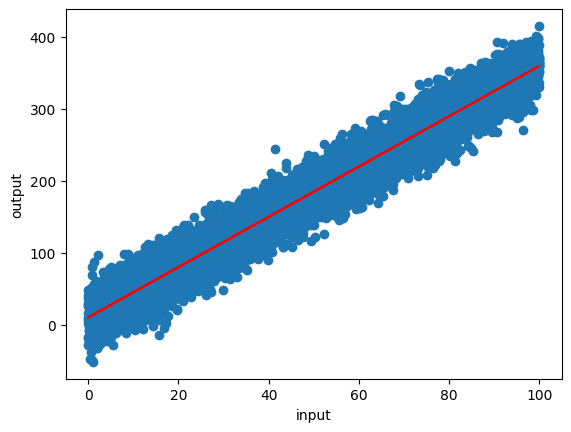

In [88]:
plt.scatter(data['input'],data['output'])
plt.plot(f_train,lr.predict(f_train.values),color='red')
plt.xlabel('input')
plt.ylabel('output')

In [89]:
g = lr.coef_

In [90]:
g

array([3.49276304])

In [91]:
b = lr.intercept_

In [44]:
b

np.float64(10.548590051558563)